<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/Project24_Reinforcement_Learning_Flappy_Bird_game_played_by_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#section 1

**project 24**

**trying to solve more sophisticated things using RL. trying to make an AI learn to play a video game on its own. we are attempting the most basic game as of now.**

**Flappy Bird**



In [62]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install pygame
!pip install pyvirtualdisplay
!pip install imageio
!pip install imageio-ffmpeg

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os


import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO

import pygame

from pyvirtualdisplay import Display

In [64]:
display = Display(visible=0,  size=(800,600))

display.start()



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [65]:
pygame.init()

(4, 1)

**ini flappy bird inte environment ezhuthanam**

In [66]:
!wget https://i.imgur.com/QZx6D8L.png -O bird.png
!wget https://i.imgur.com/2rmKZkR.png -O pipe.png
!wget https://i.imgur.com/fbgD5wR.png -O background.png

--2026-05-25 18:22:33--  https://i.imgur.com/QZx6D8L.png
Resolving i.imgur.com (i.imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to i.imgur.com (i.imgur.com)|199.232.192.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2026-05-25 18:22:33 ERROR 429: Unknown Error.

--2026-05-25 18:22:33--  https://i.imgur.com/2rmKZkR.png
Resolving i.imgur.com (i.imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to i.imgur.com (i.imgur.com)|199.232.192.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2026-05-25 18:22:33 ERROR 429: Unknown Error.

--2026-05-25 18:22:33--  https://i.imgur.com/fbgD5wR.png
Resolving i.imgur.com (i.imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to i.imgur.com (i.imgur.com)|199.232.192.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2026-05-25 18:22:33 ERROR 429: Unknown Error.



In [67]:
!rm -f bird.png
!rm -f pipe.png
!rm -f background.png

!wget "https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/yellowbird-midflap.png" -O bird.png

!wget "https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/pipe-green.png" -O pipe.png

!wget "https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/background-day.png" -O background.png

--2026-05-25 18:22:34--  https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/yellowbird-midflap.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 425 [image/png]
Saving to: ‘bird.png’

bird.png            100%[===================>]     425  --.-KB/s    in 0s      

2026-05-25 18:22:34 (12.8 MB/s) - ‘bird.png’ saved [425/425]

--2026-05-25 18:22:34--  https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/pipe-green.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2527 (2.5K) 

In [68]:
import os

print(os.path.getsize("bird.png"))
print(os.path.getsize("pipe.png"))
print(os.path.getsize("background.png"))

425
2527
7026


In [69]:
from IPython.display import Image, display

display(Image(filename='bird.png'))

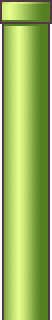

In [70]:
display(Image(filename='pipe.png'))

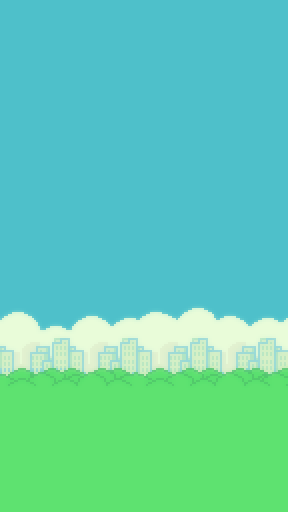

In [71]:
display(Image(filename='background.png'))

In [72]:
import random

In [108]:
class FlappyBirdEnv(gym.Env):

  def __init__(self):

    super(FlappyBirdEnv,  self).__init__()


    self.WIDTH = 400
    self.HEIGHT = 600

    self.screen = pygame.Surface((self.WIDTH,  self.HEIGHT))



    #LOAD sprites
    self.bird_sprite = pygame.image.load('bird.png')
    self.bird_sprite = pygame.transform.scale(self.bird_sprite,   (40,40))


    self.pipe_sprite = pygame.image.load('pipe.png')
    self.pipe_sprite = pygame.transform.scale(self.pipe_sprite,  (60,500))


    self.background = pygame.image.load('background.png')
    self.background = pygame.transform.scale(self.background,  (self.WIDTH, self.HEIGHT))

    # self.bird_x = 100
    # self.bird_y = 300

    ####


    #bird
    self.bird_x = 100
    self.bird_y = 300
    self.bird_velocity = 0



    #pipe
    # self.pipe_x = 400
    # self.pipe_gap = 200
    # self.pipe_top = np.random.randint(100,400)


    self.pipe_width = 60
    self.pipe_gap = 170
    self.pipe_speed = 4
    self.pipe_distance = 250

    self.pipes = []


    #gravity
    self.gravity = 0.5
    self.jump_strength = -8



    #RL spaces
    self.action_space = spaces.Discrete(2)

    self.observation_space = spaces.Box(

                                        low = -np.inf,
                                        high = np.inf,
                                        shape = (5,),
                                        dtype=np.float32
    )



    self.score = 0


    # #load sprites
    # self.bird_sprite = pygame.image.load('bird.png')
    # self.bird_sprite = pygame.transform.scale(self.bird_sprite, (40,40))


    # self.pipe_sprite = pygame.image.load('pipe.png')
    # self.pipe_sprite = pygame.transform.scale(self.pipe_sprite , (60,500))

    # self.background_sprite = pygame.image.load('background.png')
    # self.background_sprite = pygame.transform.scale(self.background_sprite, (self.WIDTH, self.HEIGHT)  )


  def create_pipe(self):

    gap_y = random.randint(150, 450)

    pipe_x = self.WIDTH

    # return {
    #     'x': pipe_x,
    #     'gap_y' : gap_y
    # }

    return {
        'x': pipe_x,
        'gap_y': gap_y,
        'passed': False
    }



  def reset(self,  seed = None, options=None):

    super().reset(seed=seed)
    self.bird_y = 300
    self.bird_velocity = 0

    self.pipe_x = 400
    self.pipe_top = np.random.randint(100,400)

    self.pipes = []

    for i in range(3):
      pipe = self.create_pipe()
      pipe['x'] +=  i * self.pipe_distance
      self.pipes.append(pipe)




    self.score = 0

    observation = self._get_obs()

    return observation, {}



  def _get_obs(self):


    #rl model game kalikkanath nammale pole visual kanditt allallo. variables inte numerical value vachitt alle
    #so avashyam illathe variables okke remove cheythat thanne rl model train cheyyumbo unnecessary 'noise' remove aavum
    #apo maybe less than 1 million lifetimes train cheyyumbo thanne better results kittumairikkum

    nearest_pipe = None

    for pipe in self.pipes:
      if pipe['x'] + self.pipe_width > self.bird_x:

        nearest_pipe = pipe
        break


    #fallback safety

    if nearest_pipe is None:
      nearest_pipe = self.pipes[0]


    pipe_x = nearest_pipe['x']


    gap_y = nearest_pipe['gap_y']



    #distance caclculate cheyyanam

    horizontal_distance = pipe_x - self.bird_x

    vertical_distance = gap_y - self.bird_y

    return np.array([
        self.bird_y,
        self.bird_velocity,
        horizontal_distance,
        vertical_distance,
        self.pipe_gap
    ],    dtype=np.float32)









      # return np.array([
      #     self.bird_y ,
      #     self.bird_velocity,
      #     self.pipe_x,
      #     self.pipe_top,
      #     self.pipe_gap
      # ], dtype=np.float32

      #                 )




  def step(self, action):

      # reward = 0.1
      reward = 0


      #Jump
      if action == 1:
        self.bird_velocity = self.jump_strength


      #now we have to gravity pull downwards
      self.bird_velocity += self.gravity

      self.bird_y += self.bird_velocity
      reward += 0.1





      # ini moving the pipe
      # self.pipe_x -= 3

      for pipe in self.pipes:
        pipe['x'] -= self.pipe_speed



      for pipe in self.pipes:

        if pipe['x']  < -self.pipe_width:
          pipe['x'] = self.WIDTH
          pipe['gap_y'] = random.randint(150,450)
          pipe['passed'] = False



      #give reward to  the rl for staying near the center
      nearest_pipe = None

      for pipe in self.pipes:
        if pipe['x'] + self.pipe_width > self.bird_x:

          nearest_pipe = pipe
          break


      if nearest_pipe is not None:
        gap_y = nearest_pipe['gap_y']
        distance_from_center = abs(self.bird_y - gap_y)

        reward += max(0,   1 - (distance_from_center/300))









      #reset pipe
      # if self.pipe_x < -50:
      #   self.pipe_x =400
      #   self.pipe_top = np.random.randint(100,400)
      #   self.score += 1
      #   reward += 10

      # oru pipe maryadayk flappy bird cross cheythaal athinu nalla reward kodukaam. so it will understand that over the course of lifetimes
      # that this is what is the aim of the flappy bird.
      for pipe in self.pipes:
        if(   pipe['x'] + self.pipe_width < self.bird_x     and          not pipe.get('passed', False)       ):
          pipe['passed'] = True
          self.score += 1
          reward += 20






      #ini collision hapen cheythaal
      done = False


      #rectangle aayitt define cheyyaam. pixel perfect collision cheyaan aayitt ith client inu shipeyaan ulla code onum allalo.
      #so rectangular sprite mathi
      bird_rect = pygame.Rect(
          self.bird_x ,
          int(self.bird_y),
          30,
          30

      )

      # top_pipe = pygame.Rect(
      #     self.pipe_x,
      #     0,
      #     50,
      #     self.pipe_top
      # )



      # bottom_pipe = pygame.Rect(
      #     self.pipe_x,
      #     self.pipe_top + self.pipe_gap,
      #     50,
      #     self.HEIGHT
      # )



    # oh, ith mathi innathek. baaki naale ezhuthaam.


    # if this works. other scenarios ilum ee RL method use cheyaan pattum. lets wait and see.
    # AI ine kond contra, dd, lionking, alladin okke kalipikaan pattiya. might be fun. but ithokke kond walla profitum generate eyaan patto nnu daivathinu ariyaam.

    # aa nokkaam. lets see.

      # if bird_rect.colliderect(top_pipe)  or bird_rect.colliderect(bottom_pipe):
      #   done = True
      #   reward = -100


      for pipe in self.pipes:

        pipe_x = pipe['x']
        gap_y = pipe['gap_y']


        #top pipe rectangle
        top_pipe_rect = pygame.Rect(
            pipe_x,
            0,
            self.pipe_width,
            gap_y - (self.pipe_gap // 2)

        )

        #bottom pipe rect
        bottom_pipe_y = gap_y + (self.pipe_gap // 2)

        bottom_pipe_rect = pygame.Rect(
            pipe_x,
            bottom_pipe_y,
            self.pipe_width,
            self.HEIGHT - bottom_pipe_y
        )

        #collsion check ezhuthanam
        if (bird_rect.colliderect(top_pipe_rect)    or    bird_rect.colliderect(bottom_pipe_rect)   ):
          done = True
          reward = -100





      if self.bird_y < 0 or self.bird_y > self.HEIGHT:
        done = True
        reward = -100


      observation = self._get_obs()


      return observation, reward, done, False, {}


  def render(self):

    self.screen.blit(self.background, (0,0))


    #top pipe
    # top_pipe_height = self.pipe_top

    # top_pipe = pygame.transform.flip(self.pipe_sprite, False, True)

    # top_pipe = pygame.transform.scale(top_pipe, (60, top_pipe_height))

    # self.screen.blit(top_pipe,   (self.pipe_x, 0))


# taking a small break. images load cheythu. render function half ezhuthi. ith theerthatt venam. RL model train cheyyaan.

# ath ethra neram edikkuvo entho..have to wait ad see if this works.display


    #bottom pipe
    # bottom_pipe_y = self.pipe_top + self.pipe_gap

    # bottom_pipe_height = self.HEIGHT - bottom_pipe_y


    # bottom_pipe = pygame.transform.scale( self.pipe_sprite,   (60,bottom_pipe_height))


    # self.screen.blit(bottom_pipe,   (self.pipe_x, bottom_pipe_y))



######################################
# we are now rendering the pipes as from an array . rl model should  understand things better if done in such manner


    for pipe in self.pipes:

      pipe_x = pipe['x']
      gap_y = pipe['gap_y']


      #top pipe
      top_pipe_height = gap_y - (self.pipe_gap // 2)

      top_pipe = pygame.transform.flip( self.pipe_sprite,  False,  True  )

      top_pipe = pygame.transform.scale(top_pipe,    (self.pipe_width , top_pipe_height))

      self.screen.blit(top_pipe,    (pipe_x, 0)   )





      #ini bottom pipe render cheyyanam

      bottom_pipe_y = gap_y + (self.pipe_gap // 2)

      bottom_pipe_height = self.HEIGHT - bottom_pipe_y

      bottom_pipe = pygame.transform.scale( self.pipe_sprite,   (self.pipe_width, bottom_pipe_height))


      self.screen.blit( bottom_pipe,  (pipe_x,   bottom_pipe_y)  )



#######################################


    #bird
    self.screen.blit( self.bird_sprite,
                     (
                      int(self.bird_x)  - 20,
                      int(self.bird_y) - 20
                     )

                      )

    return pygame.surfarray.array3d(self.screen)








ini test cheytho nokkatte

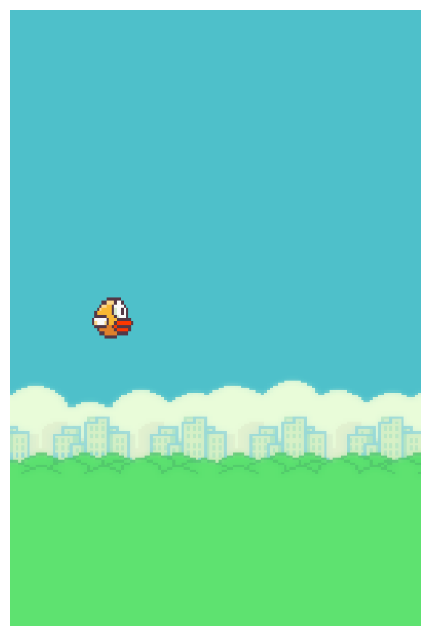

In [109]:

env = FlappyBirdEnv()

obs, _ = env.reset()

frame = env.render()


plt.figure( figsize=(6,8) )
plt.imshow(np.transpose(frame,  (1,0,2) ))
plt.axis('off')
plt.show()

In [110]:
frames = []

obs, _ = env.reset()


for i in range(100):
  action = 1 if random.random() < 0.08 else 0


  obs, reward, done, truncated, info = env.step(action)


  frame = env.render()


  frame = np.transpose(  frame,   (1,0,2) )

  frames.append(frame)




  if done:
    break


In [111]:
import imageio


imageio.mimsave( 'test_animation.gif',    frames,  duration=0.15)




In [77]:
# env = FlappyBirdEnv()

# #this sectino of code is the brain of our flappy bird. looks like oe small snetence. but its not. the neural nets behind is huge !
# model = PPO("MlpPolicy",  env,  verbose=1)



In [112]:
from IPython.display import HTML


import base64


gif_file = open('test_animation.gif', 'rb').read()

gif_base64 = base64.b64encode(gif_file).decode('utf-8')


HTML(f'''
<img src="data:image/gif;base64,  {gif_base64}">
 ''')

**ini train cheyikkaam**

In [114]:
env = FlappyBirdEnv()


# from stable_baselines import PPO

# from stable_baselines3 import PPO


model = PPO('MlpPolicy',    env,     verbose=1,       learning_rate=0.0003,     n_steps=2048,     batch_size=64,     gamma=0.99  )




Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**finally rl model itne training start chyeaan pokunnu !**

In [115]:
model.learn(total_timesteps=3_00_000)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 44.3     |
|    ep_rew_mean     | -75.2    |
| time/              |          |
|    fps             | 580      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 44.2        |
|    ep_rew_mean          | -75.7       |
| time/                   |             |
|    fps                  | 474         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005780459 |
|    clip_fraction        | 0.00605     |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.69       |
|    explained_variance   | -0.0173     |
|    learning_rate        | 0.

model onn save cheyth vachekaaam

In [116]:
model.save('ppo_flappybird_v3')

In [117]:
frames = []

obs, _ = env.reset()


for i in range(1000):
  action , _ =  model.predict(obs)



  obs, reward, done, truncated, info = env.step(action)


  frame = env.render()


  frame = np.transpose(  frame,   (1,0,2) )

  frames.append(frame)




  if done:
    break


In [120]:
import imageio


imageio.mimsave(
         'ppo_flappybird_v3.gif',
         frames,
         duration=0.03
     )



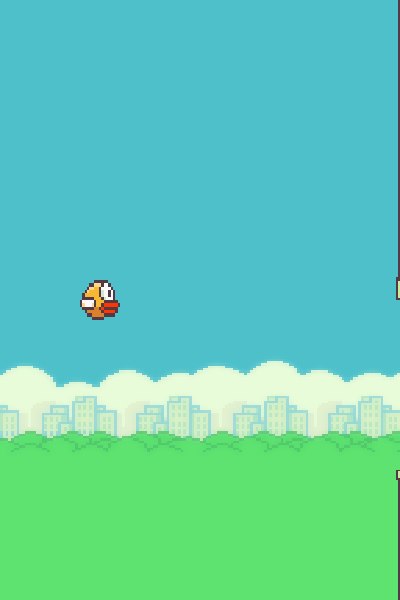

In [121]:
from IPython.display import HTML
import base64

gif_file = open("ppo_flappybird_v3.gif",'rb').read()

gif_base64 = base64.b64encode(gif_file).decode('utf-8')

HTML(f'''
<img src="data:image/gif;base64,{gif_base64}">
''')

In [83]:
# import imageio
# import numpy as np

# def record_gif(model, env, filename, max_steps=500):

#     frames = []

#     obs, _ = env.reset()

#     done = False
#     step = 0

#     while not done and step < max_steps:

#         action, _states = model.predict(
#             obs,
#             deterministic=True
#         )

#         obs, reward, done, truncated, info = env.step(action)

#         frame = env.render()

#         # Rotate correctly
#         frame = np.transpose(frame, (1,0,2))

#         # Convert to uint8
#         frame = frame.astype(np.uint8)

#         frames.append(frame)

#         step += 1

#     print("Frames captured:", len(frames))

#     imageio.mimsave(
#         filename,
#         frames,
#         duration=0.03
#     )

#     print("GIF saved:", filename)